In [1]:
# Import Libraries and Modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Confusion Matrix Plot (Binary Classification)
def plot_cm(cm, ax, title, cmap):
    """ Plots a labeled confusion matrix with TN/FP/FN/TP annotations """

    # Label each cell with confusion matrix meaning
    group_names = np.array([["TN", "FP"],
                            ["FN", "TP"]])

    # Format raw counts with commas
    labels = np.array([[f"{cm[0,0]:,}", f"{cm[0,1]:,}"],
                       [f"{cm[1,0]:,}", f"{cm[1,1]:,}"]])

    # Combine label type + value in each cell
    annot = np.array([[f"{group_names[0,0]}\n{labels[0,0]}",
                       f"{group_names[0,1]}\n{labels[0,1]}"],
                      [f"{group_names[1,0]}\n{labels[1,0]}",
                       f"{group_names[1,1]}\n{labels[1,1]}"]])

    # Heatmap visualisation
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=cmap,
        cbar=False,
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"],
        ax=ax,
        annot_kws={"fontsize": 14}
    )

    # Axis labels and title
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


In [3]:
def plot_accuracy_comparison(models, binary_acc, multiclass_acc):
    """ Plots a bar chart comparing binary and multi-class accuracy for each model """
    
    # X-axis positions
    x = np.arange(len(models))

    # Width of each bar
    width = 0.35

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Binary accuracy bars
    bars_bin = ax.bar(
        x - width/2,
        binary_acc,
        width,
        color='blue',
        label="Binary Accuracy"
    )

    # Multi-class accuracy bars
    bars_multi = ax.bar(
        x + width/2,
        multiclass_acc,
        width,
        color='lightblue',
        label="Multi-Class Accuracy"
    )

    # Axis labels and ticks
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Model")
    ax.set_xticks(x)
    ax.set_xticklabels(models)

    # Accuracy range
    ax.set_ylim(99.2, 99.9)

    # Add binary accuracy values above bars
    for i, bar in enumerate(bars_bin):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{binary_acc[i]:.4f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Add multi-class accuracy values above bars
    for i, bar in enumerate(bars_multi):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{multiclass_acc[i]:.4f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Chart title
    plt.title("Binary vs Multi-Class Detection Accuracy Comparison")

    # Show legend
    ax.legend()

    plt.tight_layout()
    plt.show()

In [15]:
def compute_cm_percent(y_true, y_pred, labels):
    """ Computes raw matrix count and normalised matrix percentages """

    # Compute raw confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Convert counts into row-wise percentages
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Replace NaNs
    cm_percent = np.nan_to_num(cm_percent)

    return cm, cm_percent


def plot_class_cm(ax, cm, cm_pct, title):
    """ Plot CM heatmap showing raw counts and percentages """

    # Create annotation matrix with same shape as confusion matrix
    annot = np.empty_like(cm, dtype=object)

    # Fill each cell with formatted string
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]:,}\n({cm_pct[i, j]:.2f}%)"

    # Plot heatmap using percentage values for color scaling
    sns.heatmap(
        cm_pct,
        ax=ax,
        cmap="Blues",
        cbar=False,
        annot=annot,
        fmt="",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    # Titles and axis labels
    ax.set_title(title)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.tick_params(axis='x', rotation=45)

Validation data analysis

In [ ]:
# List of models used 
model_cols = ["LSTM", "DNN", "RF"]

# Validation prediction file
INPUT_FILE = "predictions/saved/predictions_val_final.csv"

# Load prediction results
df_final = pd.read_csv(INPUT_FILE)

# Ground truth labels
y_true = df_final["Actual"]

# Convert labels into binary format
y_true_bin = (df_final["Actual"].str.lower() != "benign").astype(int)

# Compute accuracies

# Binary Classification Accuracy
print("Binary accuracies:")
accuracies = {m: accuracy_score(y_true_bin, (df_final[m].str.lower() != "benign").astype(int)) for m in model_cols}
accuracies["Majority"] = accuracy_score(y_true_bin, (df_final["Majority"].str.lower() != "benign").astype(int))
accuracies["Weighted"] = accuracy_score(y_true_bin, (df_final["Weighted"].str.lower() != "benign").astype(int))
print(accuracies)

# Multi-Class Classification Accuracy
print("Per-class accuracies:")
accuracies = {m: accuracy_score(y_true, df_final[m]) for m in model_cols}
accuracies["Majority"] = accuracy_score(y_true, df_final["Majority"])
accuracies["Weighted"] = accuracy_score(y_true, df_final["Weighted"])

print(accuracies)

Binary accuracies:
{'LSTM': 0.9971845508591772, 'DNN': 0.9940406380560658, 'RF': 0.996995622105745, 'Majority': 0.9968074499319889, 'Weighted': 0.997350890305134}
Per-class accuracies:
{'LSTM': 0.9969733570467021, 'DNN': 0.9934750407066887, 'RF': 0.9968860261355045, 'Majority': 0.9966073886490351, 'Weighted': 0.9972238930023405}


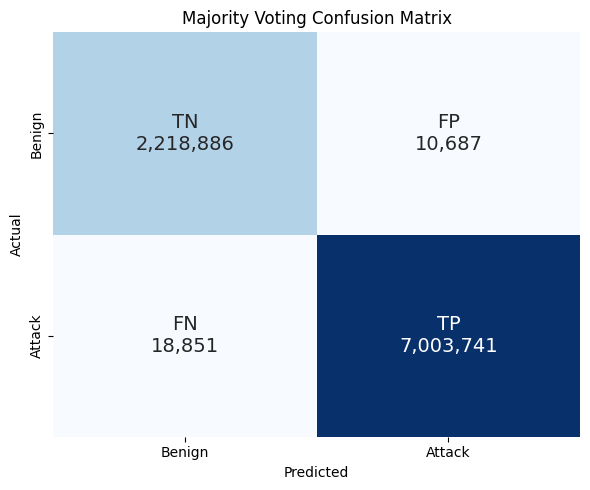

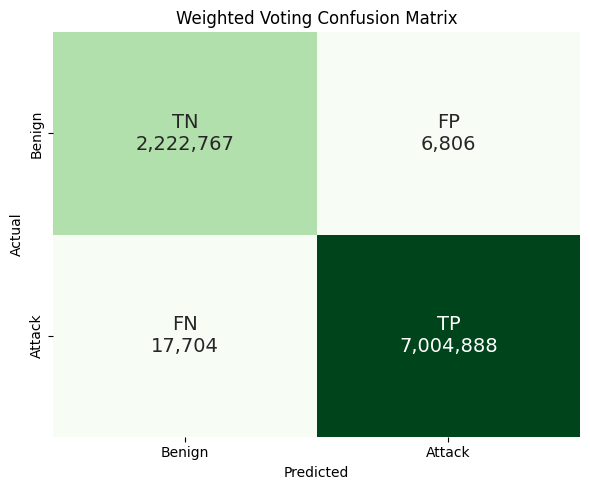

In [4]:
# Load prediction results
df = pd.read_csv(INPUT_FILE)

# Convert labels into binary classes
def to_binary(label):
    return "Benign" if label == "Benign" else "Attack"


# Convert to binary
df["Actual_bin"] = df["Actual"].apply(to_binary)
df["Majority_bin"] = df["Majority"].apply(to_binary)
df["Weighted_bin"] = df["Weighted"].apply(to_binary)

# Generate confusion matrices
cm_majority = confusion_matrix(
    df["Actual_bin"],
    df["Majority_bin"],
    labels=["Benign", "Attack"]
)

cm_weighted = confusion_matrix(
    df["Actual_bin"],
    df["Weighted_bin"],
    labels=["Benign", "Attack"]
)

# Plot Majority Voting CM
fig, ax = plt.subplots(figsize=(6, 5))

plot_cm(
    cm_majority,
    ax,
    "Majority Voting Confusion Matrix",
    "Blues"
)

plt.tight_layout()
plt.show()

# Plot Weighted Voting CM
fig, ax = plt.subplots(figsize=(6, 5))

plot_cm(
    cm_weighted,
    ax,
    "Weighted Voting Confusion Matrix",
    "Greens"
)

plt.tight_layout()
plt.show()

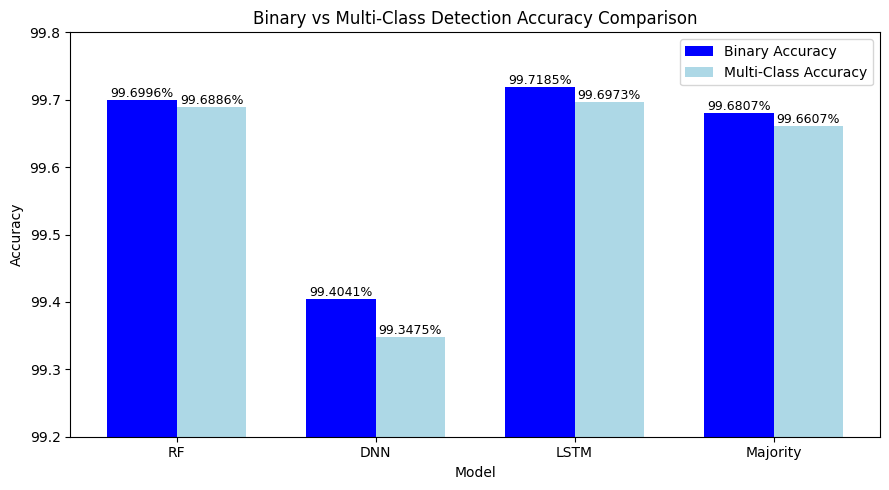

In [ ]:
# List of models
models = ["RF", "DNN", "LSTM", "Majority"]

# Binary classification accuracies (%)
binary_acc = [
    99.6996,
    99.4041,
    99.7185,
    99.6807
]

# Multi-class classification accuracies (%)
multiclass_acc = [
    99.6886,
    99.3475,
    99.6973,
    99.6607
]

plot_accuracy_comparison(models, binary_acc, multiclass_acc)

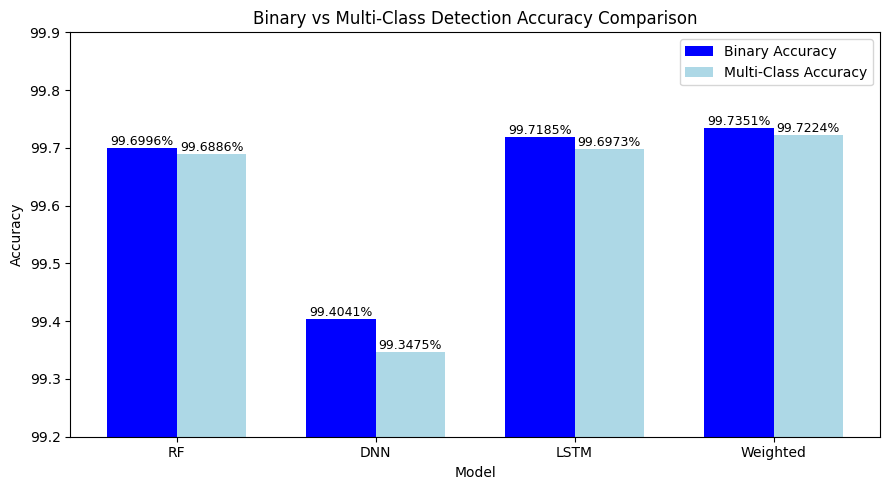

In [ ]:
# List of models
models = ["RF", "DNN", "LSTM", "Weighted"]

# Binary classification accuracies (%)
binary_acc = [
    99.6996,
    99.4041,
    99.7185,
    99.7351
]

# Multi-class classification accuracies (%)
multiclass_acc = [
    99.6886,
    99.3475,
    99.6973,
    99.7224
]

plot_accuracy_comparison(models, binary_acc, multiclass_acc)

Test data analysis

In [5]:
# List of models used 
model_cols = ["LSTM", "DNN", "RF"]

# Validation prediction file
INPUT_FILE = "predictions/saved/predictions_test_final.csv"

# Load prediction results
df_final = pd.read_csv(INPUT_FILE)

# Ground truth labels
y_true = df_final["Actual"]

# Convert labels into binary format
y_true_bin = (df_final["Actual"].str.lower() != "benign").astype(int)

# Compute accuracies

# Binary Classification Accuracy
print("Binary accuracies:")
accuracies = {m: accuracy_score(y_true_bin, (df_final[m].str.lower() != "benign").astype(int)) for m in model_cols}
accuracies["Majority"] = accuracy_score(y_true_bin, (df_final["Majority"].str.lower() != "benign").astype(int))
accuracies["Weighted"] = accuracy_score(y_true_bin, (df_final["Weighted"].str.lower() != "benign").astype(int))
print(accuracies)

# Multi-Class Classification Accuracy
print("Per-class accuracies:")
accuracies = {m: accuracy_score(y_true, df_final[m]) for m in model_cols}
accuracies["Majority"] = accuracy_score(y_true, df_final["Majority"])
accuracies["Weighted"] = accuracy_score(y_true, df_final["Weighted"])

print(accuracies)

Binary accuracies:
{'LSTM': 0.9971828215342031, 'DNN': 0.9940933824677791, 'RF': 0.9969833006653037, 'Majority': 0.9968066933523126, 'Weighted': 0.9973481882348618}
Per-class accuracies:
{'LSTM': 0.9969736812951348, 'DNN': 0.993532648844892, 'RF': 0.9968705702935475, 'Majority': 0.9966046865787629, 'Weighted': 0.9972229202570425}


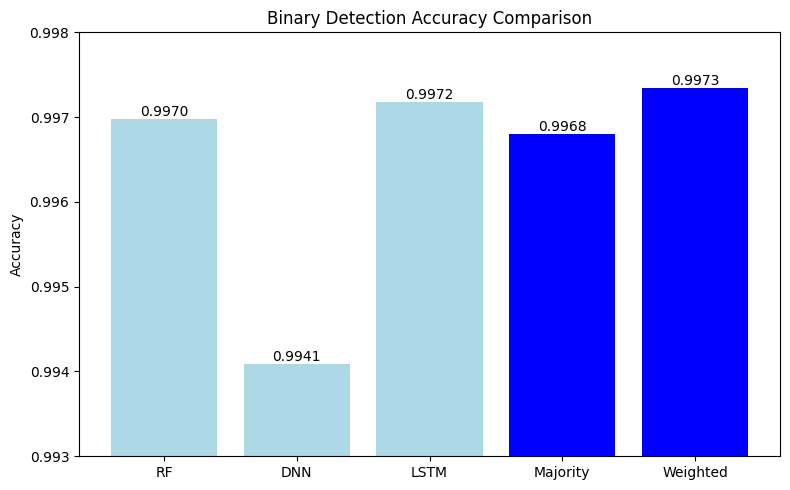

In [6]:
# Binary detection accuracies for each model
accuracies = {
    'LSTM': 0.9971828215342031,
    'DNN': 0.9940933824677791,
    'RF': 0.9969833006653037,
    'Majority': 0.9968066933523126,
    'Weighted': 0.9973481882348618
}

# List of models
models = ['RF', 'DNN', 'LSTM', 'Majority', 'Weighted']
colors = ['lightblue', 'lightblue', 'lightblue', 'blue', 'blue']

# Extract accuracy values
values = [accuracies[m] for m in models]

# Create figure
plt.figure(figsize=(8, 5))

# Plot bar chart
bars = plt.bar(models, values, color=colors)

# Axis labels and title
plt.ylabel("Accuracy")
plt.title("Binary Detection Accuracy Comparison")

# Add accuracy values above bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{value:.4f}",
             ha='center', va='bottom')

# Set y-axis range
plt.ylim(0.993, 0.998)
plt.tight_layout()
plt.show()

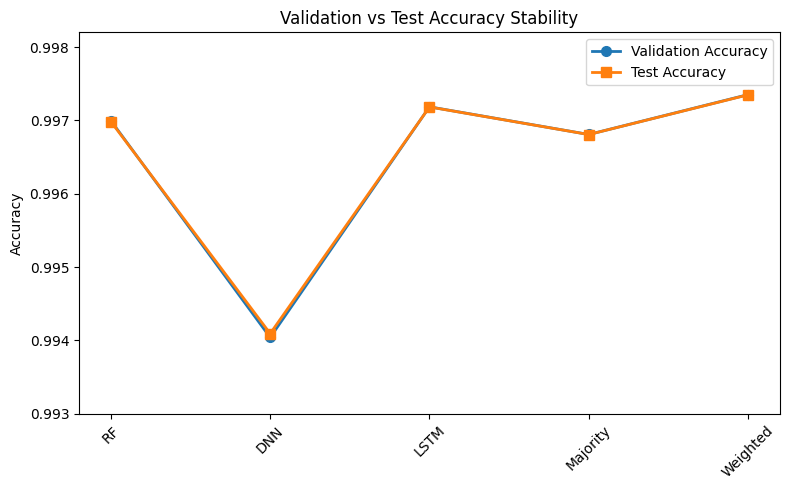

In [ ]:
# Results on test / validation sets
test_acc = {'RF': 0.9969833006653037, 'DNN': 0.9940933824677791,'LSTM': 0.9971828215342031, 'Majority': 0.9968066933523126, 'Weighted': 0.9973481882348618}
val_acc = {'RF': 0.996995622105745, 'DNN': 0.9940406380560658, 'LSTM': 0.9971845508591772, 'Majority': 0.9968074499319889, 'Weighted': 0.997350890305134}

# Ensure consistent model ordering
models = list(test_acc.keys())

# Extract values
test_values = [test_acc[m] for m in models]
val_values = [val_acc[m] for m in models]

# Create figure
plt.figure(figsize=(8,5))

# Validation line
plt.plot(models, val_values, marker='o', markersize=7, linewidth=2)

# Test line
plt.plot(models, test_values, marker='s', markersize=7, linewidth=2)

# Axis formatting
plt.ylim(0.9930, 0.9982)
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy Stability")

plt.legend(["Validation Accuracy", "Test Accuracy"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# List of models
model_cols = ["LSTM", "DNN", "RF", "Majority", "Weighted"]

# Input file containing final test predictions
INPUT_FILE = "predictions/saved/predictions_test_final.csv"

# Load dataset with predictions from all models
df_final = pd.read_csv(INPUT_FILE)

# Ground truth (binary: 0 = benign, 1 = attack)
y_true_bin = (df_final["Actual"].str.lower() != "benign").astype(int)

print("Binary Confusion Matrices:\n")

# Binary confusion matrix per model
for model in model_cols:
    
    # Convert predictions to binary
    y_pred_bin = (df_final[model].str.lower() != "benign").astype(int)
    
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    
    print(f"{model}:")
    print(cm)
    print()

Binary Confusion Matrices:

LSTM:
[[2217622   12004]
 [  14061 7008478]]

DNN:
[[2198759   30867]
 [  23782 6998757]]

RF:
[[2220865    8761]
 [  19150 7003389]]

Majority:
[[2218943   10683]
 [  18862 7003677]]

Weighted:
[[2222851    6775]
 [  17760 7004779]]



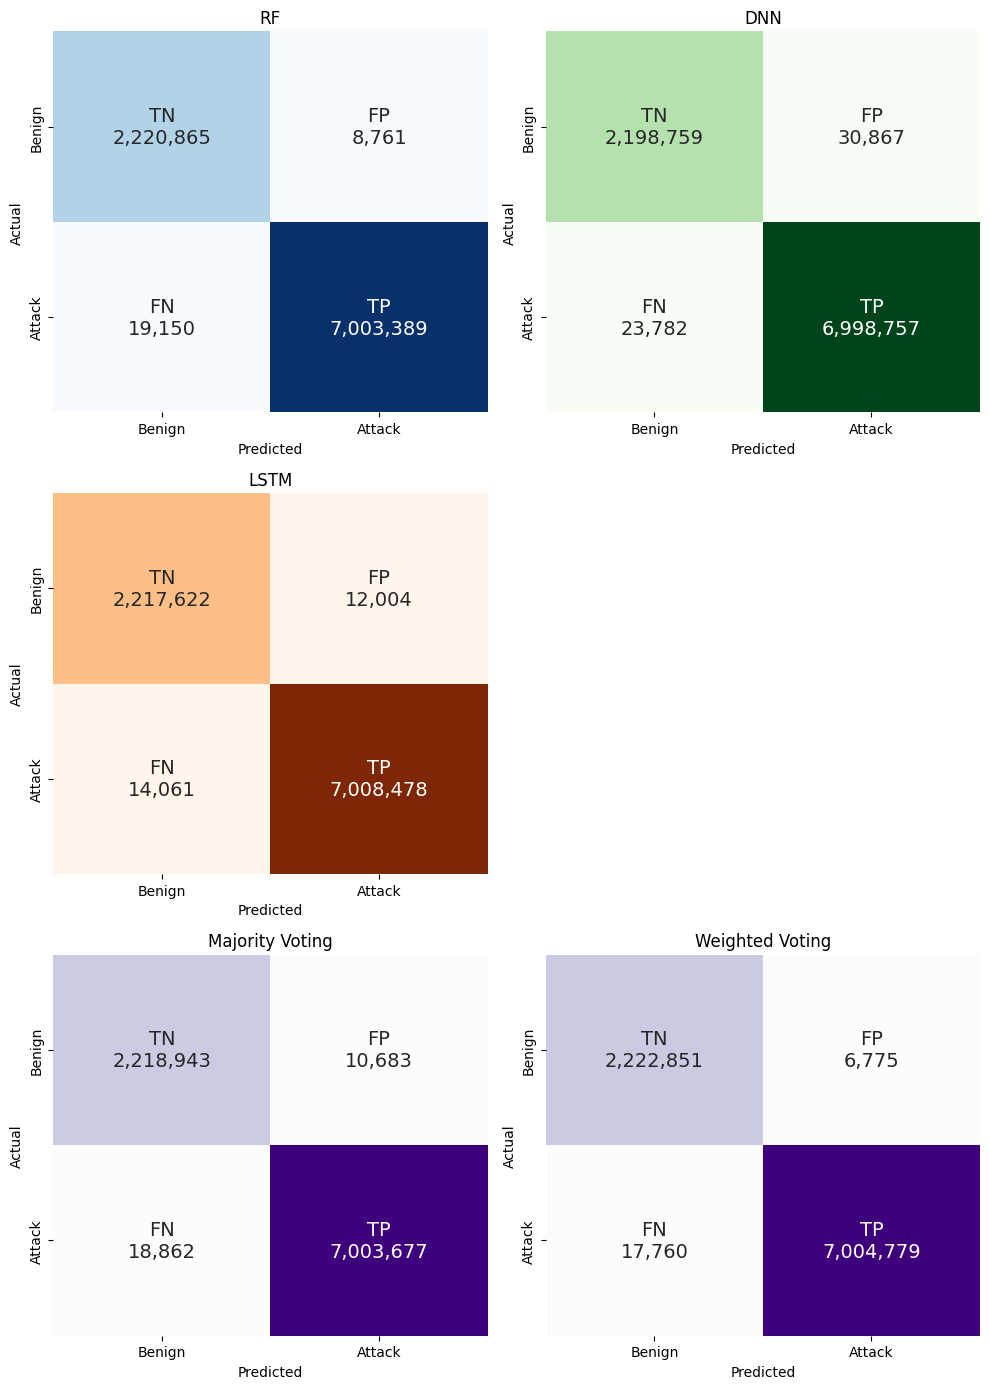

In [ ]:
# Confusion matrices
cm_lstm = np.array([[2217622, 12004], [14061, 7008478]])
cm_dnn = np.array([[2198759, 30867], [23782, 6998757]])
cm_rf = np.array([[2220865, 8761], [19150, 7003389]])
cm_majority = np.array([[2218943, 10683], [18862, 7003677]])
cm_weighted = np.array([[2222851, 6775], [17760, 7004779]])

plt.figure(figsize=(10, 14))

# Row 1
plt.subplot(3, 2, 1)
plot_cm(cm_rf, plt.gca(), "RF", "Blues")

plt.subplot(3, 2, 2)
plot_cm(cm_dnn, plt.gca(), "DNN", "Greens")

# Row 2 
plt.subplot(3, 2, 3)
plot_cm(cm_lstm, plt.gca(), "LSTM", "Oranges")

# Row 3
plt.subplot(3, 2, 5)
plot_cm(cm_majority, plt.gca(), "Majority Voting", "Purples")

plt.subplot(3, 2, 6)
plot_cm(cm_weighted, plt.gca(), "Weighted Voting", "Purples")

plt.tight_layout()
plt.show()

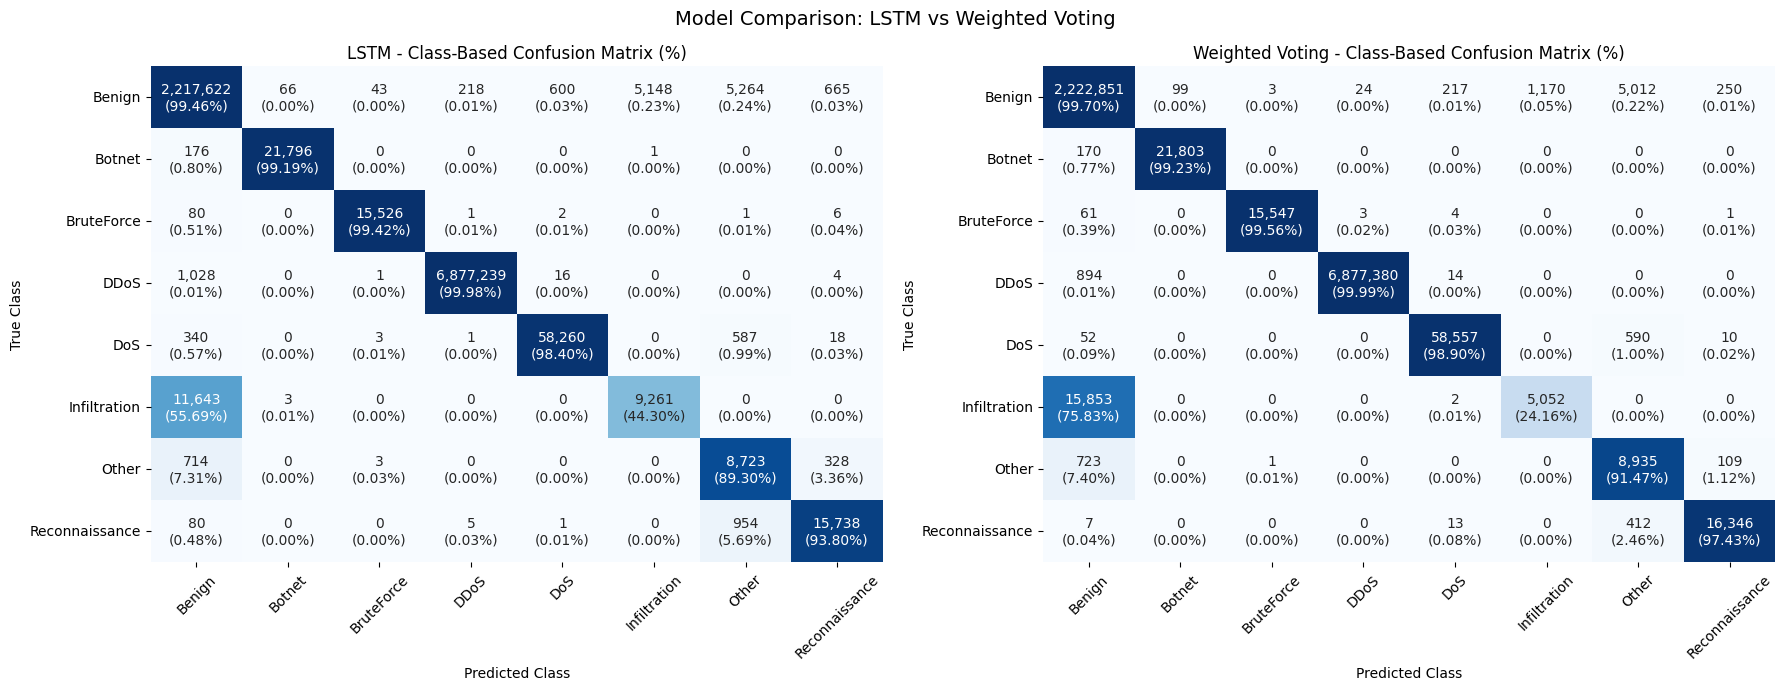

In [17]:
# Load prediction results
INPUT_FILE = "predictions/saved/predictions_test_final.csv"
df = pd.read_csv(INPUT_FILE)

# Actual label and model predictions
y_true = df["Actual"]
y_lstm = df["LSTM"]
y_weighted = df["Weighted"]

# Ensure consistent class ordering
class_labels = sorted(y_true.unique())

# Compute confusion matrices for both models
cm_lstm, cm_lstm_pct = compute_cm_percent(y_true, y_lstm, class_labels)
cm_w, cm_w_pct = compute_cm_percent(y_true, y_weighted, class_labels)

# Plot both models
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_class_cm(axes[0], cm_lstm, cm_lstm_pct, "LSTM - Class-Based Confusion Matrix (%)")
plot_class_cm(axes[1], cm_w, cm_w_pct, "Weighted Voting - Class-Based Confusion Matrix (%)")

plt.suptitle("Model Comparison: LSTM vs Weighted Voting", fontsize=14)
plt.tight_layout()
plt.show()

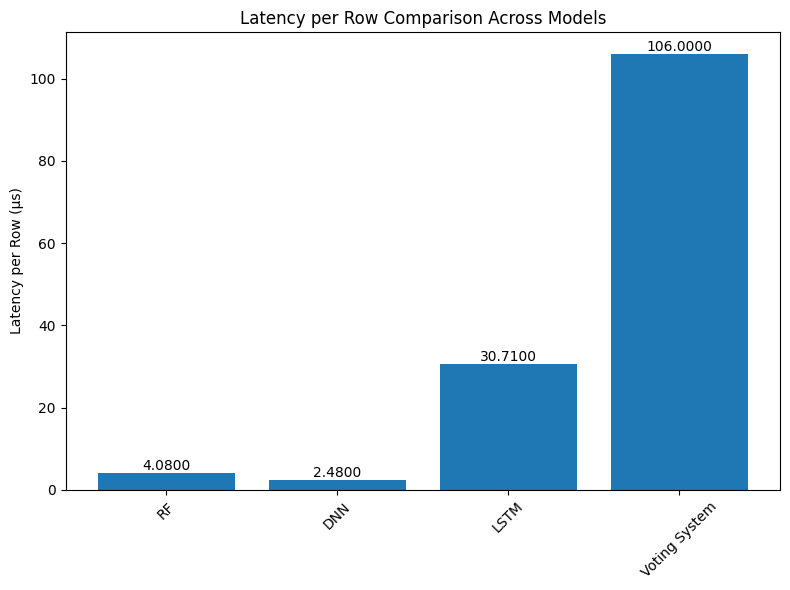

In [ ]:
# Latency values (microseconds per row)
models = ["RF", "DNN", "LSTM", "Voting System"]
latency = [4.08, 2.48, 30.71, 106.00]

# Create figure
plt.figure(figsize=(8,6))

# Plot bar chart of latency values
bars = plt.bar(models, latency)

# Axis labels and title
plt.ylabel("Latency per Row (μs)")
plt.title("Latency per Row Comparison Across Models")
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

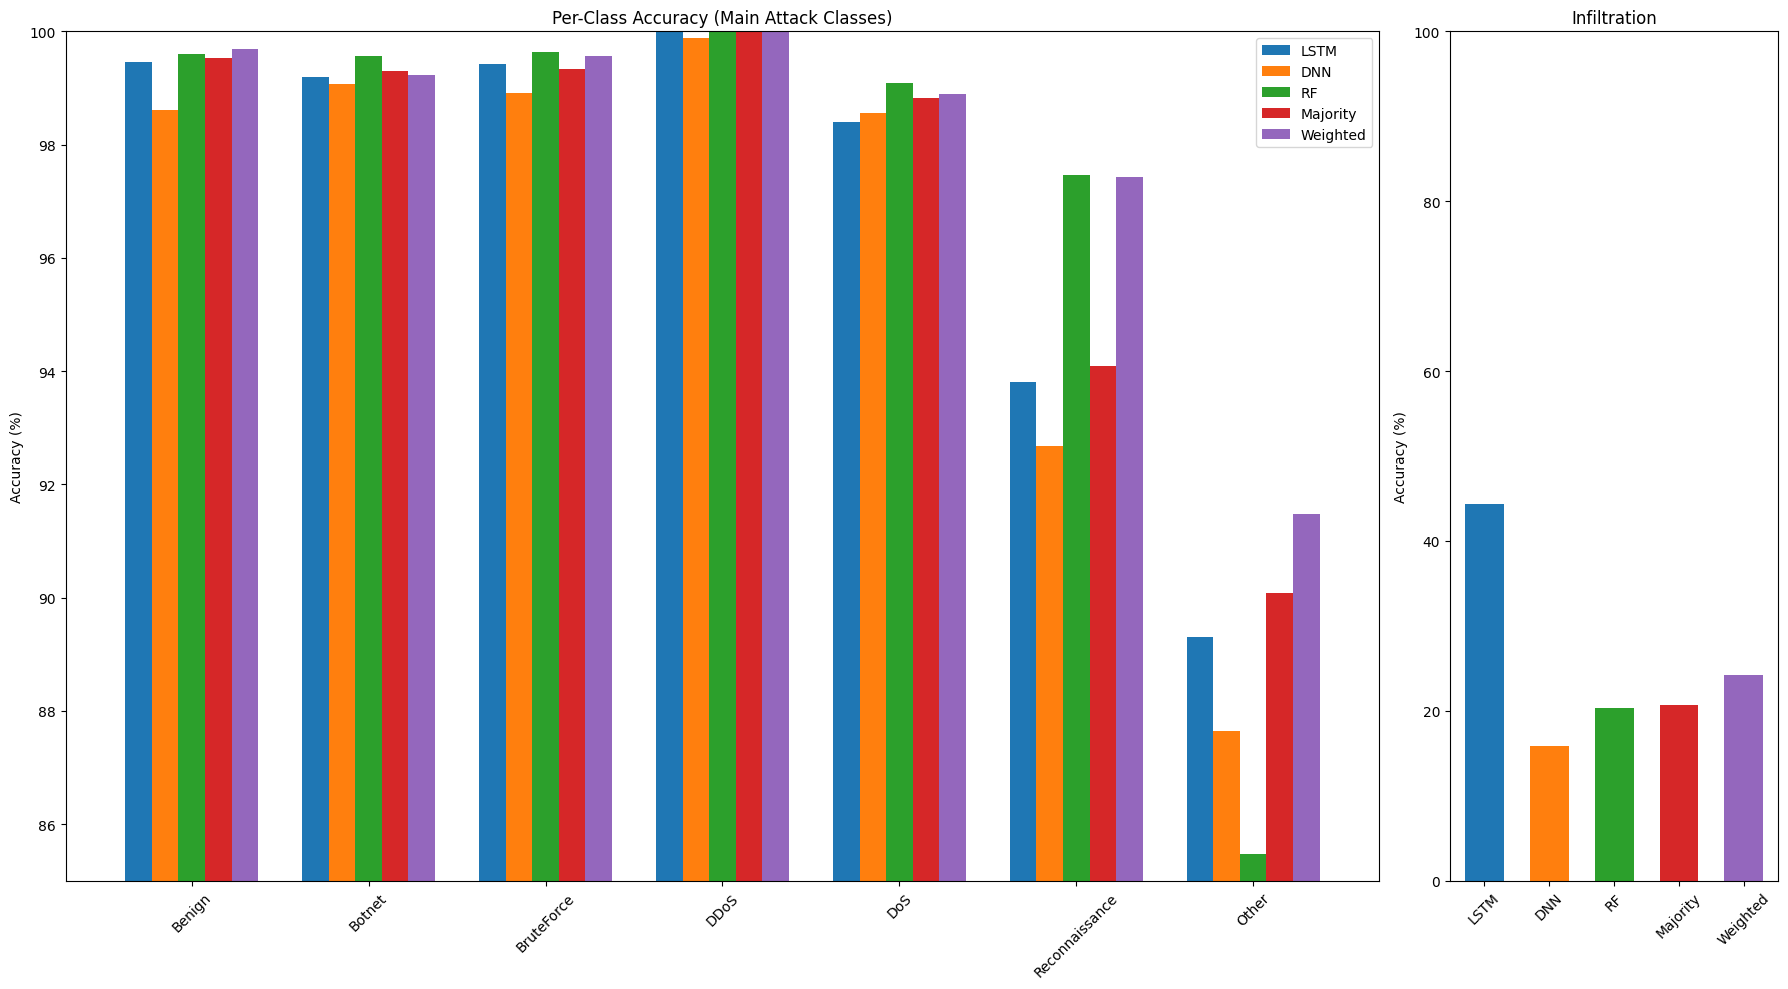

In [ ]:
# Load prediction results
INPUT_FILE = "predictions/saved/predictions_test_final.csv"
df = pd.read_csv(INPUT_FILE)

# Models being evaluated
models = ["LSTM", "DNN", "RF", "Majority", "Weighted"]

# Class order for consistent plotting
classes = [
    "Benign", "Botnet", "BruteForce", "DDoS",
    "DoS", "Reconnaissance", "Other", "Infiltration"
]

# Store per-class accuracy results per model
results = {}

for model in models:
    class_acc = []

    # Compute accuracy for each class independently
    for cls in classes:
        mask = df["Actual"] == cls

        # Compare predictions vs actual label for this class only
        acc = (df.loc[mask, model] == df.loc[mask, "Actual"]).mean()

        # Convert to percentage
        class_acc.append(acc * 100)

    results[model] = class_acc


# Split classes into main attack classes + Infiltration
infiltration_idx = classes.index("Infiltration")
main_classes = classes[:-1]
main_idx = list(range(len(main_classes)))

x = np.arange(len(main_classes))
width = 0.15

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 10),
    gridspec_kw={"width_ratios": [4, 1]}
)

# LEFT PLOT (Main classes)
for i, model in enumerate(models):
    ax1.bar(
        x + i * width,
        [results[model][j] for j in main_idx],
        width,
        label=model
    )

ax1.set_title("Per-Class Accuracy (Main Attack Classes)")
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(main_classes, rotation=45)
ax1.set_ylim(85, 100)
ax1.set_ylabel("Accuracy (%)")
ax1.legend()

# RIGHT PLOT (Infiltration only)
for i, model in enumerate(models):
    ax2.bar(
        i,
        results[model][infiltration_idx],
        width=0.6
    )

ax2.set_title("Infiltration")
ax2.set_xticks(np.arange(len(models)))
ax2.set_xticklabels(models, rotation=45)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

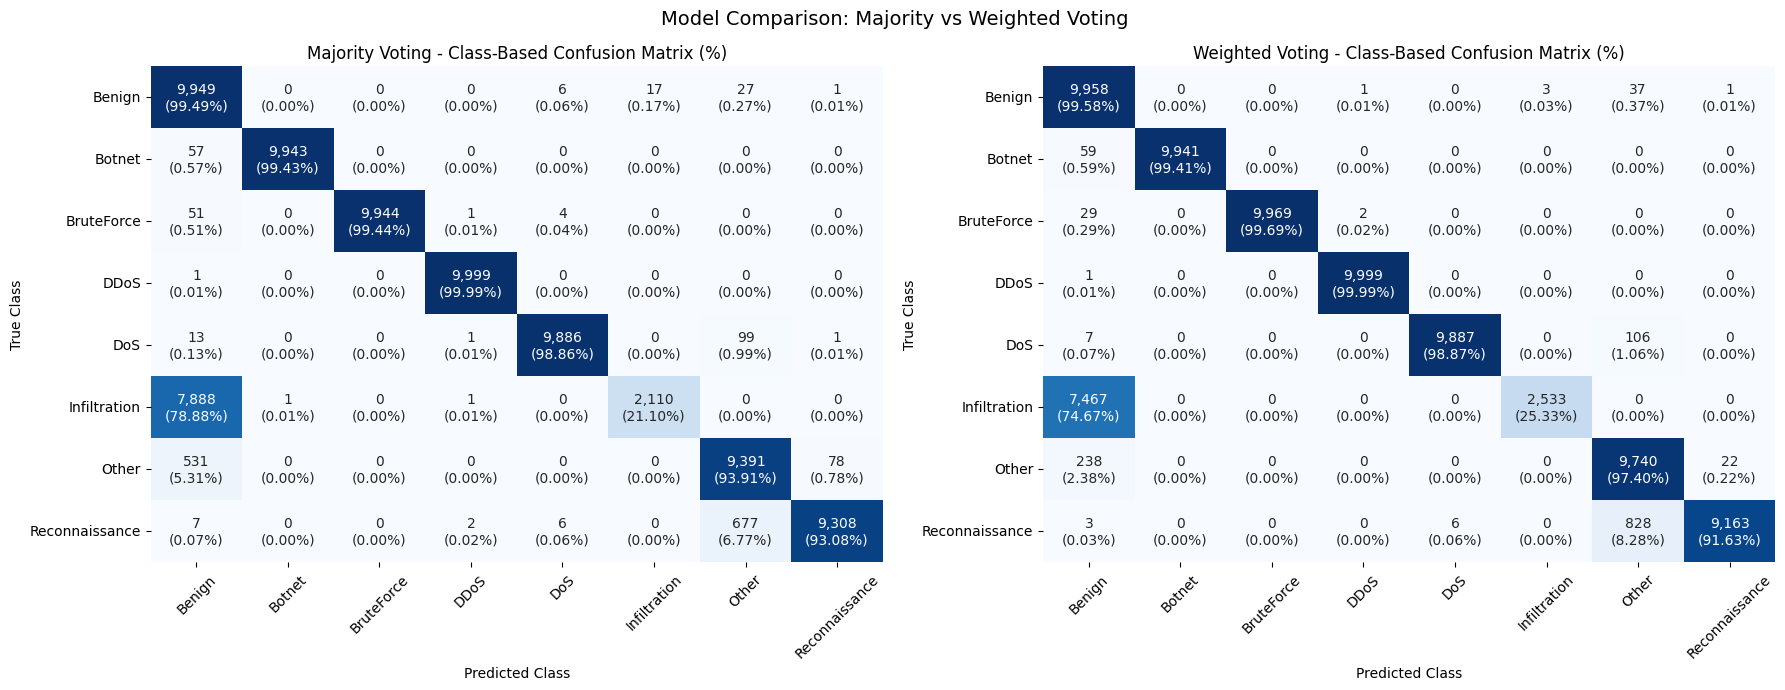

In [18]:
# Load prediction results
INPUT_FILE = "predictions/predictions_final.csv"
df = pd.read_csv(INPUT_FILE)

# Actual label and model predictions
y_true = df["Actual"]
y_majority = df["Majority"]
y_weighted = df["Weighted"]

# Ensure consistent class ordering
class_labels = sorted(y_true.unique())

# Compute confusion matrices for both models
cm_m, cm_m_pct = compute_cm_percent(y_true, y_majority, class_labels)
cm_w, cm_w_pct = compute_cm_percent(y_true, y_weighted, class_labels)

# Plot both models
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_class_cm(axes[0], cm_m, cm_m_pct, "Majority Voting - Class-Based Confusion Matrix (%)")
plot_class_cm(axes[1], cm_w, cm_w_pct, "Weighted Voting - Class-Based Confusion Matrix (%)")

plt.suptitle("Model Comparison: Majority vs Weighted Voting", fontsize=14)
plt.tight_layout()
plt.show()

Results per dataset

In [ ]:
# Load predictions and oringial test dataset
pred_df = pd.read_csv("predictions/saved/predictions_test_final.csv")
test_df = pd.read_csv("data/cleaned/partitioned/test.csv")

# Create copy to merge dataset origin info
df = pred_df.copy()

# Add dataset source
df["Dataset"] = test_df["Dataset"]

# Actual labels
y_true = df["Actual"]

# Dictionary to store accuracy results per dataset per model
results = {}

# Loop over each dataset
for dataset_name in df["Dataset"].unique():

    # Filter rows belonging to the current dataset
    subset = df[df["Dataset"] == dataset_name]
    
    # Initialise dictionary for this dataset
    results[dataset_name] = {}
    
    # Compute accuracy for each model on this dataset subset
    for model in model_cols:
        acc = accuracy_score(subset["Actual"], subset[model])
        results[dataset_name][model] = acc

# Convert to DataFrame for clean display
results_df = pd.DataFrame(results).T
print(results_df)

                      LSTM       DNN        RF  Majority  Weighted
cic-unsw-nb15     0.978284  0.975408  0.986976  0.979011  0.982148
cic-ids-2017      0.997026  0.970038  0.998522  0.997383  0.998451
cse-cic-ids-2018  0.989862  0.979506  0.987046  0.987732  0.989969
cic-ddos-2019     0.999865  0.999481  0.999854  0.999840  0.999875


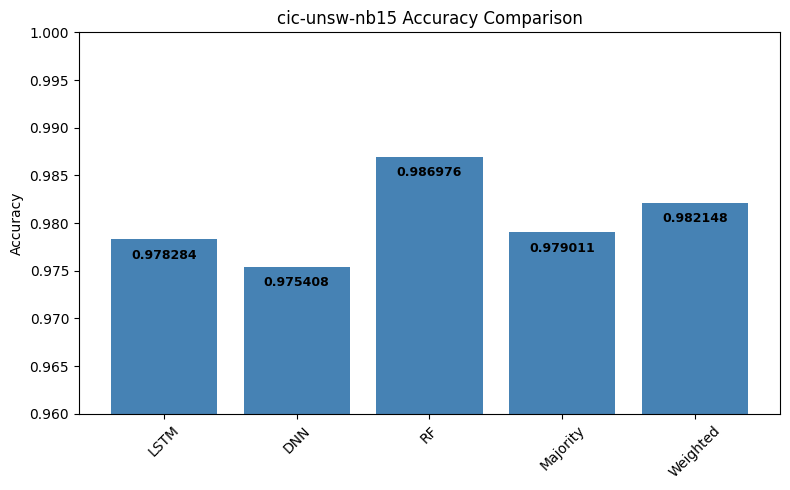

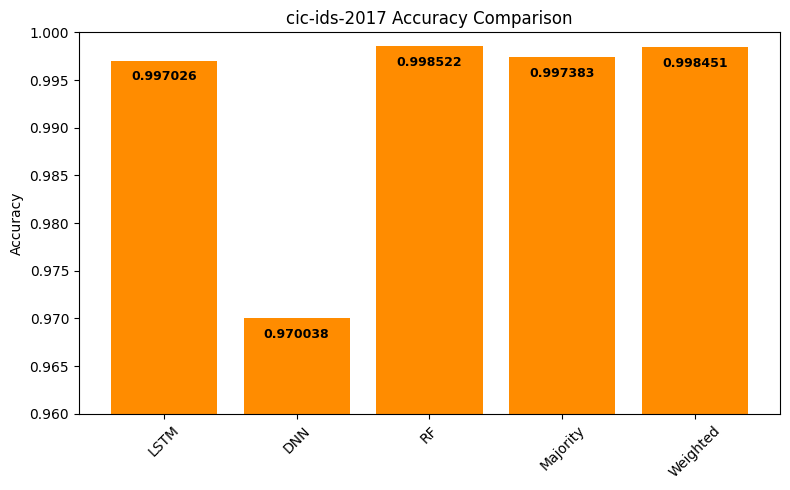

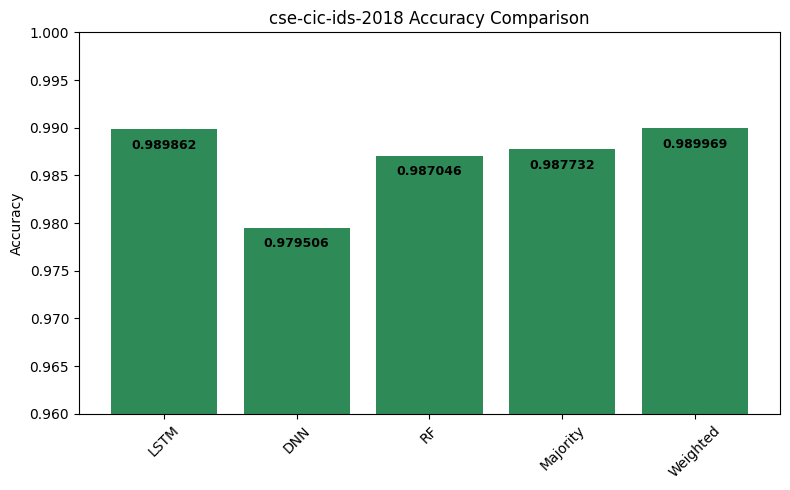

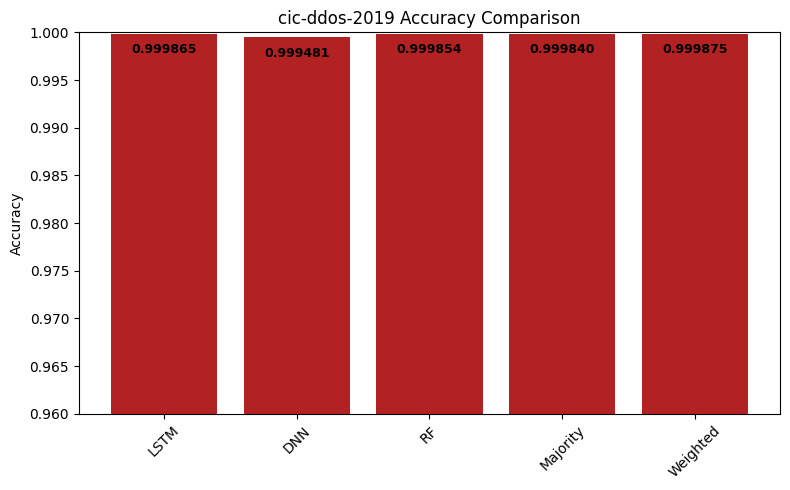

In [ ]:
# Color mapping for each dataset
dataset_colors = {
    "cic-unsw-nb15": "steelblue",
    "cic-ids-2017": "darkorange",
    "cse-cic-ids-2018": "seagreen",
    "cic-ddos-2019": "firebrick"
}

# Create a separate bar chart for each dataset
for dataset_name, model_scores in results.items():

    # Extract model names and their corresponding accuracy values
    models = list(model_scores.keys())
    accuracies = list(model_scores.values())

    # Create new figure per dataset
    plt.figure(figsize=(8,5))

    # Plot bar chart for model comparison within this dataset
    bars = plt.bar(models, accuracies, color=dataset_colors[dataset_name])

    # Set y-axis range
    plt.ylim(0.96, 1.0)

    # Axis labels and title
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} Accuracy Comparison")

    # Add numeric labels on each bar
    for i, v in enumerate(accuracies):
        plt.text(i, v - 0.001, f"{v:.6f}", 
                ha='center', va='top', fontsize=9, fontweight='bold')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()